In [1]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os

from fractal_dim.utils import fractal_analysis
from nibabel.freesurfer.io import read_geometry 
from sys import platform

# using recon-all
Nice theory, but not working well / at all on source dhcp.  

## 1 Get the volume

In [1]:
niftipath = "code/volumes/IXI002-Guys-0828-T1.nii.gz"

## 2 Recon-all

export SUBJECTS_DIR=/Users/arnaud/Documents/GitHub/RESEARCH-MRI-Analysis/code/volumes/

Do in terminal, given fs installation :

``` recon-all -s OUTPUTDIR -i IXI002-Guys-0828-T1.nii.gz -all ```

While looking for a script to apply recon-all to my local install of the dhcp dataset, I realised that some samples only have T2 but none only have T1.  
There are 558 subjects, this should give 1116 scan of cumulated T1 + T2.  
I only have 1050 because 66 of them are T2 only.  
Subject : 558  
T1 scans: 492  
T2 scans: 558  
This is verified with *scandata.sh*

In [36]:
!./looprecon.sh

Total folders: 558
Total files: 984
Unique T1 files: 0
Unique T2 files: 66


1974811

The first attempt at recon all al the files from dhcp is in *looprecon.sh*. Files are in recon_out with session ids. 

## 3 Read Niftis and pials

In [ ]:
out = read_geometry("001/surf/lh.pial", read_metadata=True)
out[0].shape, out[1].shape

((130843, 3), (261682, 3))

In [13]:
out[2]

OrderedDict([('head', array([ 2,  0, 20], dtype=int32)),
             ('valid', '1  # volume info valid'),
             ('filename',
              '/Users/arnaud/Documents/GitHub/RESEARCH-MRI-Analysis/code/volumes/001/mri/wm.mgz'),
             ('volume', array([256, 256, 256])),
             ('voxelsize', array([1., 1., 1.])),
             ('xras',
              array([-1.00000012e+00,  0.00000000e+00, -1.32348898e-23])),
             ('yras',
              array([ 0.00000000e+00,  1.49011612e-08, -1.00000012e+00])),
             ('zras', array([0.00000000e+00, 1.00000012e+00, 1.49011612e-08])),
             ('cras', array([ 1.35987854, 12.23675537, 21.76138306]))])

playing with nifti

In [2]:
ixi_img = nib.load('IXI002-Guys-0828-T1.nii.gz')
ixi_img_data = ixi_img.get_fdata()
ixi_img_data.shape

(256, 256, 150)

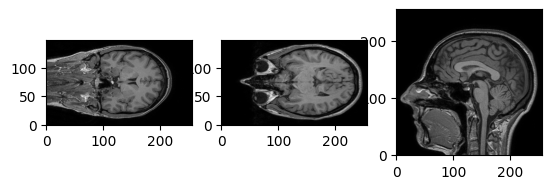

In [9]:
# looking at slices
def show_slices(slices):
   """ Function to display row of image slices """
   fig, axes = plt.subplots(1, len(slices))
   for i, slice in enumerate(slices):
       axes[i].imshow(slice.T, cmap="gray", origin="lower")

slice_0 = ixi_img_data[128, :, :]
slice_1 = ixi_img_data[:, 128, :]
slice_2 = ixi_img_data[:, :, 75]
show_slices([slice_0, slice_1, slice_2])

In [34]:
aff = np.array([[-1, 0, 0],
          [0, 0, -1],
          [0, 1, 0]])

np.dot(np.array([128, 128, 75]), aff)

array([-128,   75, -128])

In [ ]:
# central voxel value
ixi_img_data[128, 128, 75]

151.0

In [31]:
np.set_printoptions(precision=3, suppress=True)
aff = ixi_img.affine
M = aff[:3, :3]
abc = aff[:3, 3]
aff, M, abc

(array([[   0.   ,    0.   ,    1.2  ,  -88.64 ],
        [  -0.93 ,    0.116,    0.   ,  116.532],
        [   0.116,    0.93 ,   -0.   , -112.114],
        [   0.   ,    0.   ,    0.   ,    1.   ]]),
 array([[ 0.   ,  0.   ,  1.2  ],
        [-0.93 ,  0.116,  0.   ],
        [ 0.116,  0.93 , -0.   ]]),
 array([ -88.64 ,  116.532, -112.114]))

# Using synthseg
An automatic segmentation tool, significantly faster and easier to use than the whole freesurfer pipeline. 

In [1]:
!python3 synthseg_loop.py

Total dhcp T1w :492
Already started files : 1/492.
{'sub-CC00060XX03_ses-12501'}
Already Completed files 1/492. 

Skipping already processed and logged : sub-CC00060XX03 ses-12501 

Newly completed files 0


Synthseg was completed on bobs, and source segmentation also available.  
The synthseg output is the equivalent of the aseg from freesurfer, and assigns labels to each voxel of the input.  
From this we create a separate nifti for each segmented (and detected ) part

In [6]:
# Freesurfer label mapping
if platform == "darwin":
    fs_lut = "/Applications/freesurfer/FreeSurferColorLUT.txt"
elif platform == "linux":
    fs_lut = "/usr/local/freesurfer/7.4.1/FreeSurferColorLUT.txt"
index_to_label = {}
with open(fs_lut, 'r') as file:
    for line in file:
        # comments or empty
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()
        index = int(parts[0])
        label_name = ' '.join(parts[1:-4])
        index_to_label[index] = label_name

In [3]:
index_to_label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 192, 86, 87, 88, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 176, 170, 171, 172, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 23

In [5]:
aseg_source = nib.load('/home/data/mri_datasets/bobs/sub-116056/ses-3mo/anat/sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg.nii.gz')
# aseg_source = nib.load('/Users/arnaud/Downloads/bobs_mri/sub-116056/ses-3mo/anat/sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg.nii.gz')
print("Unique source labels :")
print(np.unique(aseg_source.get_fdata()).astype(int))


aseg_synth = nib.load('./mri_segs/bobs/sub-116056_ses-3mo_synthseg_robust_cpu_mac.nii.gz')
print("Unique labels from synthseg : ")
print(np.unique(aseg_synth.get_fdata()).astype(int)) 

aseg_synth_parc = nib.load('./mri_segs/bobs/sub-116056_ses-3mo_synthseg_robust_parc_cpu_mac.nii.gz')
print("Unique labels from synthseg with parcellation: ")
print(np.unique(aseg_synth_parc.get_fdata()).astype(int))


Unique source labels :
[  0   2   3   4   5   7   8  10  11  12  13  14  15  16  17  18  26  28
  31  41  42  43  44  46  47  49  50  51  52  53  54  58  60  63 172]
Unique labels from synthseg : 
[ 0  2  3  4  5  7  8 10 11 12 13 14 15 16 17 18 24 26 28 41 42 43 44 46
 47 49 50 51 52 53 54 58 60]
Unique labels from synthseg with parcellation: 
[   0    2    4    5    7    8   10   11   12   13   14   15   16   17
   18   24   26   28   41   43   44   46   47   49   50   51   52   53
   54   58   60 1001 1002 1003 1005 1006 1007 1008 1009 1010 1011 1012
 1013 1014 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026
 1027 1028 1029 1030 1031 1032 1033 1034 1035 2001 2002 2003 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034
 2035]


In [6]:
# 
set1 = set(np.unique(aseg_source.get_fdata()).astype(int))
set2 = set(np.unique(aseg_synth.get_fdata()).astype(int))

in_set1_not_in_set2 = set1 - set2
in_set2_not_in_set1 = set2 - set1

print("Elements in sourceseg but not in synthsseg:", in_set1_not_in_set2)
print("Elements in synthsseg but not in sourceseg:", in_set2_not_in_set1)

Elements in sourceseg but not in synthsseg: {172, 63, 31}
Elements in synthsseg but not in sourceseg: {24}


All labels in common between source seg, synthseg, and synthseg with parc:

In [11]:
common_lbls = list(set(np.unique(aseg_synth.get_fdata()).astype(int)) & set(np.unique(aseg_synth_parc.get_fdata()).astype(int)) & set(np.unique(aseg_source.get_fdata()).astype(int)))
print(common_lbls)

[0, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28, 41, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 58, 60]


Note that there is no added parts that the original seg did not know about.  
And since the parcellation is done, some parts are not present under the same name in the parc segmentation (expected).

In [12]:
common_lbls = list(set(np.unique(aseg_synth.get_fdata()).astype(int)) & set(np.unique(aseg_source.get_fdata()).astype(int)))
print(common_lbls)

[0, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28, 41, 42, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 58, 60]


## Saving segmentations

Using only the parcellation segmentations, first.

In [40]:
aseg_synth_parc = nib.load('./mri_segs/bobs/sub-116056_ses-3mo_synthseg_robust_parc_cpu_mac.nii.gz')
aseg_synth_parc.get_fdata().shape

(182, 218, 182)

In [43]:
seg_part_aparc = aseg_synth_parc.get_fdata().astype(int)
np.unique(seg_part_aparc.astype(int))

array([   0,    2,    4,    5,    7,    8,   10,   11,   12,   13,   14,
         15,   16,   17,   18,   24,   26,   28,   41,   43,   44,   46,
         47,   49,   50,   51,   52,   53,   54,   58,   60, 1001, 1002,
       1003, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014,
       1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025,
       1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 2001,
       2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035])

In [3]:
# Directory to save the segmentation files
output_dir = "synthseg/nifti"
os.makedirs(output_dir, exist_ok=True)
aseg_synth_parc = nib.load('./mri_segs/bobs/sub-116056_ses-3mo_synthseg_robust_parc_cpu_mac.nii.gz')
seg_part_aparc = aseg_synth_parc.get_fdata().astype(int)
# seg_part_aseg = (arr_aseg == lbl)
# seg_part_src = (arr_src == lbl)

print(f"Labels", labels:=np.unique(seg_part_aparc.astype(int)))

Labels [   0    2    4    5    7    8   10   11   12   13   14   15   16   17
   18   24   26   28   41   43   44   46   47   49   50   51   52   53
   54   58   60 1001 1002 1003 1005 1006 1007 1008 1009 1010 1011 1012
 1013 1014 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026
 1027 1028 1029 1030 1031 1032 1033 1034 1035 2001 2002 2003 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034
 2035]


In [ ]:
# Loop through labels and save each segmentation
for lbl in np.unique(seg_part_aparc.astype(int)):

    if seg_part_aparc.astype(int).any():

        # Create and save NIfTI images for each segmentation
        label_img_nii_aparc = nib.Nifti1Image(seg_part_aparc.astype(int), aseg_synth_parc.affine, aseg_synth_parc.header)
        nib.save(label_img_nii_aparc, os.path.join(output_dir, f"{lbl}_{index_to_label[lbl]}_aparc.nii.gz"))

        print(f"{lbl}_{index_to_label[lbl]} detected and saved")
        # label_img_nii_src = nib.Nifti1Image(seg_part_src.astype(int), aseg_source.affine, aseg_source.header)
        # nib.save(label_img_nii_src, os.path.join(output_dir, f"{lbl}_{index_to_label[lbl]}_src.nii.gz"))

    else:
        print(f"{lbl}_{index_to_label[lbl]}  X no seg")

## Comparing FD of all 3 segs

In [8]:
arr_aseg, arr_aparc, arr_src =  aseg_synth.get_fdata(), aseg_synth_parc.get_fdata(), aseg_source.get_fdata()
# for lbl in index_to_label.keys():
# Up to 60 only for now, faster 
for lbl in common_lbls:
    seg_part_aseg = (arr_aseg == lbl)
    seg_part_aparc = (arr_aparc == lbl)
    seg_part_src = (arr_src == lbl)
    # print(seg_part.size)
    if seg_part_aseg.astype(np.uint8).any():
        print(f"{lbl}_{index_to_label[lbl]} detected")

        # Seg to Nifti 
        label_img_nii_aseg = nib.Nifti1Image(seg_part_aseg.astype(np.uint8), aseg_synth.affine, aseg_synth.header)
        label_img_nii_aparc = nib.Nifti1Image(seg_part_aparc.astype(np.uint8), aseg_synth_parc.affine, aseg_synth_parc.header)
        label_img_nii_src = nib.Nifti1Image(seg_part_src.astype(np.uint8), aseg_source.affine, aseg_source.header)
        # test FD
        print(f"FD with synthseg no parc {fractal_analysis(label_img_nii_aseg)}")
        print(f"FD with synthseg + parc {fractal_analysis(label_img_nii_aparc)}") # expected to be identical
        print(f"FD with source segmentation {fractal_analysis(label_img_nii_src)}")
        # Nifti save
        # nib.save(label_img_nii, f"synthseg/nifti/{lbl}_{index_to_label[lbl]}.nii.gz")
        # MGZ (freesurfer format)
        # nib.save(label_img_nii, f"synthseg/mgz/{lbl}_{index_to_label[lbl]}.mgz")

    else : print(f"{lbl}_{index_to_label[lbl]}  X no seg")

FD with synthseg no parc 2.8977
FD with synthseg + parc 2.8977
FD with source segmentation 2.8446
0_Unknown detected
FD with synthseg no parc 2.4882
FD with synthseg + parc 2.4882
FD with source segmentation 2.4704
2_Left-Cerebral-White-Matter detected
FD with synthseg no parc 1.4089
FD with synthseg + parc 1.4089
FD with source segmentation 1.5052
4_Left-Lateral-Ventricle detected
FD with synthseg no parc 1.1902
FD with synthseg + parc 1.1902
FD with source segmentation 1.3861
5_Left-Inf-Lat-Vent detected
FD with synthseg no parc 2.0791
FD with synthseg + parc 2.0791
FD with source segmentation 2.1183
7_Left-Cerebellum-White-Matter detected
FD with synthseg no parc 2.4744
FD with synthseg + parc 2.4744
FD with source segmentation 2.4195
8_Left-Cerebellum-Cortex detected
FD with synthseg no parc 2.2716
FD with synthseg + parc 2.2716
FD with source segmentation 2.3187
10_Left-Thalamus detected
FD with synthseg no parc 1.9658
FD with synthseg + parc 1.9658
FD with source segmentation 2.0

KeyboardInterrupt: 

### Dhcp segs

In [2]:
from glob import glob
from natsort import natsorted
segs = natsorted(glob("./mri_segs/dhcp/parc/*.nii.gz"))
# len(segs)
segs[0]


'./mri_segs/dhcp/parc/sub-CC00058XX09_ses-11300_T2w_MNI_synthseg_robust_parc_cpu_frodo.nii.gz'

In [3]:
aseg_synth_parc = nib.load(segs[0])
aseg_synth_parc.get_fdata().shape

(195, 233, 159)

In [4]:
seg_part_aparc = aseg_synth_parc.get_fdata().astype(int)
np.unique(seg_part_aparc.astype(int))

array([   0,    2,    4,    5,    7,    8,   10,   11,   12,   13,   14,
         15,   16,   17,   18,   24,   26,   28,   41,   43,   44,   46,
         47,   49,   50,   51,   52,   53,   54,   58,   60, 1001, 1002,
       1003, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014,
       1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025,
       1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 2001,
       2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035])

In [5]:
for lbl in np.unique(seg_part_aparc.astype(int)):
    print(index_to_label[lbl])

NameError: name 'index_to_label' is not defined

In [23]:
leftsides = [2, 4, 5, 7, 8, 10, 11, 12, 13, 17, 18, 26, 28] + [i for i in range(1001, 1036, 1)]
righsides = [41, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 58, 60] + [i for i in range(2001, 2036, 1)]

In [34]:
leftmask = np.isin(seg_part_aparc, leftsides)
rightmask = np.isin(seg_part_aparc, righsides)
# Set values not in the allowed list to 0
left_hemi = np.where(leftmask, seg_part_aparc, 0)
right_hemi = np.where(rightmask, seg_part_aparc, 0)

In [35]:
niftileft = nib.Nifti1Image(left_hemi.astype(np.uint8), aseg_synth_parc.affine, aseg_synth_parc.header)
nib.save(niftileft, f"left_hemi_11300T2.nii.gz")
niftiright = nib.Nifti1Image(right_hemi.astype(np.uint8), aseg_synth_parc.affine, aseg_synth_parc.header)
nib.save(niftiright, f"right_hemi_11300T2.nii.gz")

In [37]:
print(f"FD whole brain {fractal_analysis(aseg_synth_parc)}")

FD whole 2.8241


In [38]:
print(f"FD left {fractal_analysis(niftileft)}")
print(f"FD right {fractal_analysis(niftiright)}")

FD left 2.7355
FD right 2.739
